In [47]:
import h5py
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
base_path = Path(r"C:\Users\lab\Documents\ALDBot Data")

spec_dicts = []

for h5path in base_path.glob("**/*.h5"):
    #print(repr(h5path))
    try:
        with h5py.File(h5path,'r') as h5f:
            #print(h5f)
            M = h5f['measurement'][list(h5f['measurement'].keys())[0]]
            oes_spec = np.array(M['oes_spec'])
            oes_spec_time = np.array(M['oes_spec_time'])
            oes_spec_cycle = np.array(M['oes_spec_cycle'])
            cycle_start_time = np.array(M['cycle_start_time'])
            dataset_id = h5f.attrs['unique_id']
            #print(dataset_id)
            #print(oes_spec)
            for i, spec in enumerate(oes_spec):
                if oes_spec_time[i] < 1:
                    continue
                time_since_cycle_start = oes_spec_time[i] - cycle_start_time[oes_spec_cycle[i]]
                spec_dict = {'run_id':dataset_id, 'spec':spec, 
                            'time':oes_spec_time[i], 'cycle':oes_spec_cycle[i], 'time_since_cycle_start': time_since_cycle_start}
                spec_dicts.append(spec_dict)

    except Exception as err:
        print("Error", err)
    #text_file = next(base_path.glob('**/*.h5'))
    #parent_dir = text_file.parent.resolve()


specs_df = pd.DataFrame(spec_dicts)
specs_df
specs_df = specs_df.sort_values(by='time').reset_index(drop=True)
specs_df

Error Unable to open file (bad object header version number)
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec' doesn't exist)"
Error "Unable to open object (object 'oes_spec_time' doesn't exist)"
Error "Unable to open object (object 'oes_spec_time' doesn't exist)"
Error index 1 is out of bounds for axis 0 with size 1
Error index 1 is out of bounds for axis 0 w

,run_id,spec,time,cycle,time_since_cycle_start
0,0sszpz6kdxvnv000j2d1385dbm,"[-3.929836677006633, -3.929836677006633, -3.92...",1.732229e+09,0,8.155806
1,0sszpz6kdxvnv000j2d1385dbm,"[4.277427171091787, 4.277427171091787, 4.27742...",1.732229e+09,0,8.254067
2,0sszpz6kdxvnv000j2d1385dbm,"[-16.518949078020825, -16.518949078020825, -16...",1.732229e+09,0,8.331350
3,0sszpz6kdxvnv000j2d1385dbm,"[3.8795543627129536, 3.8795543627129536, 3.879...",1.732229e+09,0,8.427597
4,0sszpz6kdxvnv000j2d1385dbm,"[-1.9897222502475094, -1.9897222502475094, -1....",1.732229e+09,0,8.507838
...,...,...,...,...,...
22493,0st7d5xqxnygd000zrbxvm6j1g,"[-13.532880743549173, -13.532880743549173, -13...",1.732734e+09,49,11.160224
22494,0st7d5xqxnygd000zrbxvm6j1g,"[11.13984850832018, 11.13984850832018, 11.1398...",1.732734e+09,49,11.257362
22495,0st7d5xqxnygd000zrbxvm6j1g,"[-18.111647999514997, -18.111647999514997, -18...",1.732734e+09,49,11.368508
22496,0st7d5xqxnygd000zrbxvm6j1g,"[22.971109160825716, 22.971109160825716, 22.97...",1.732734e+09,49,11.500097


: 

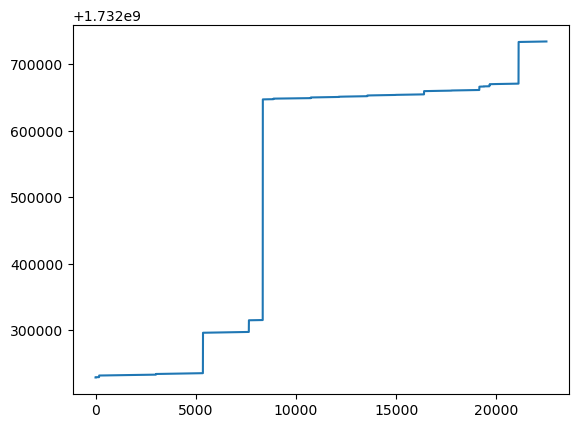

In [56]:
plt.plot(specs_df['time'])

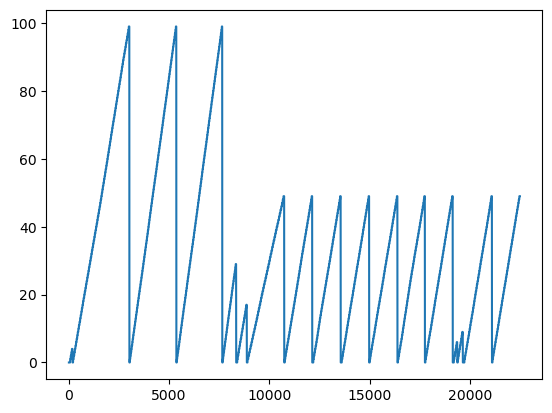

In [57]:
plt.plot(specs_df['cycle'])

(0.0, 1000.0)

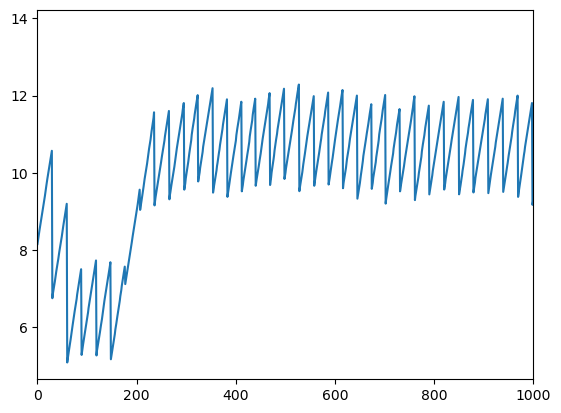

In [59]:
plt.plot(specs_df['time_since_cycle_start'])
plt.xlim(0,1000)

# Notes

Looks like we should be recording plasma start time, not just cycle start time


(10, 5000.0)

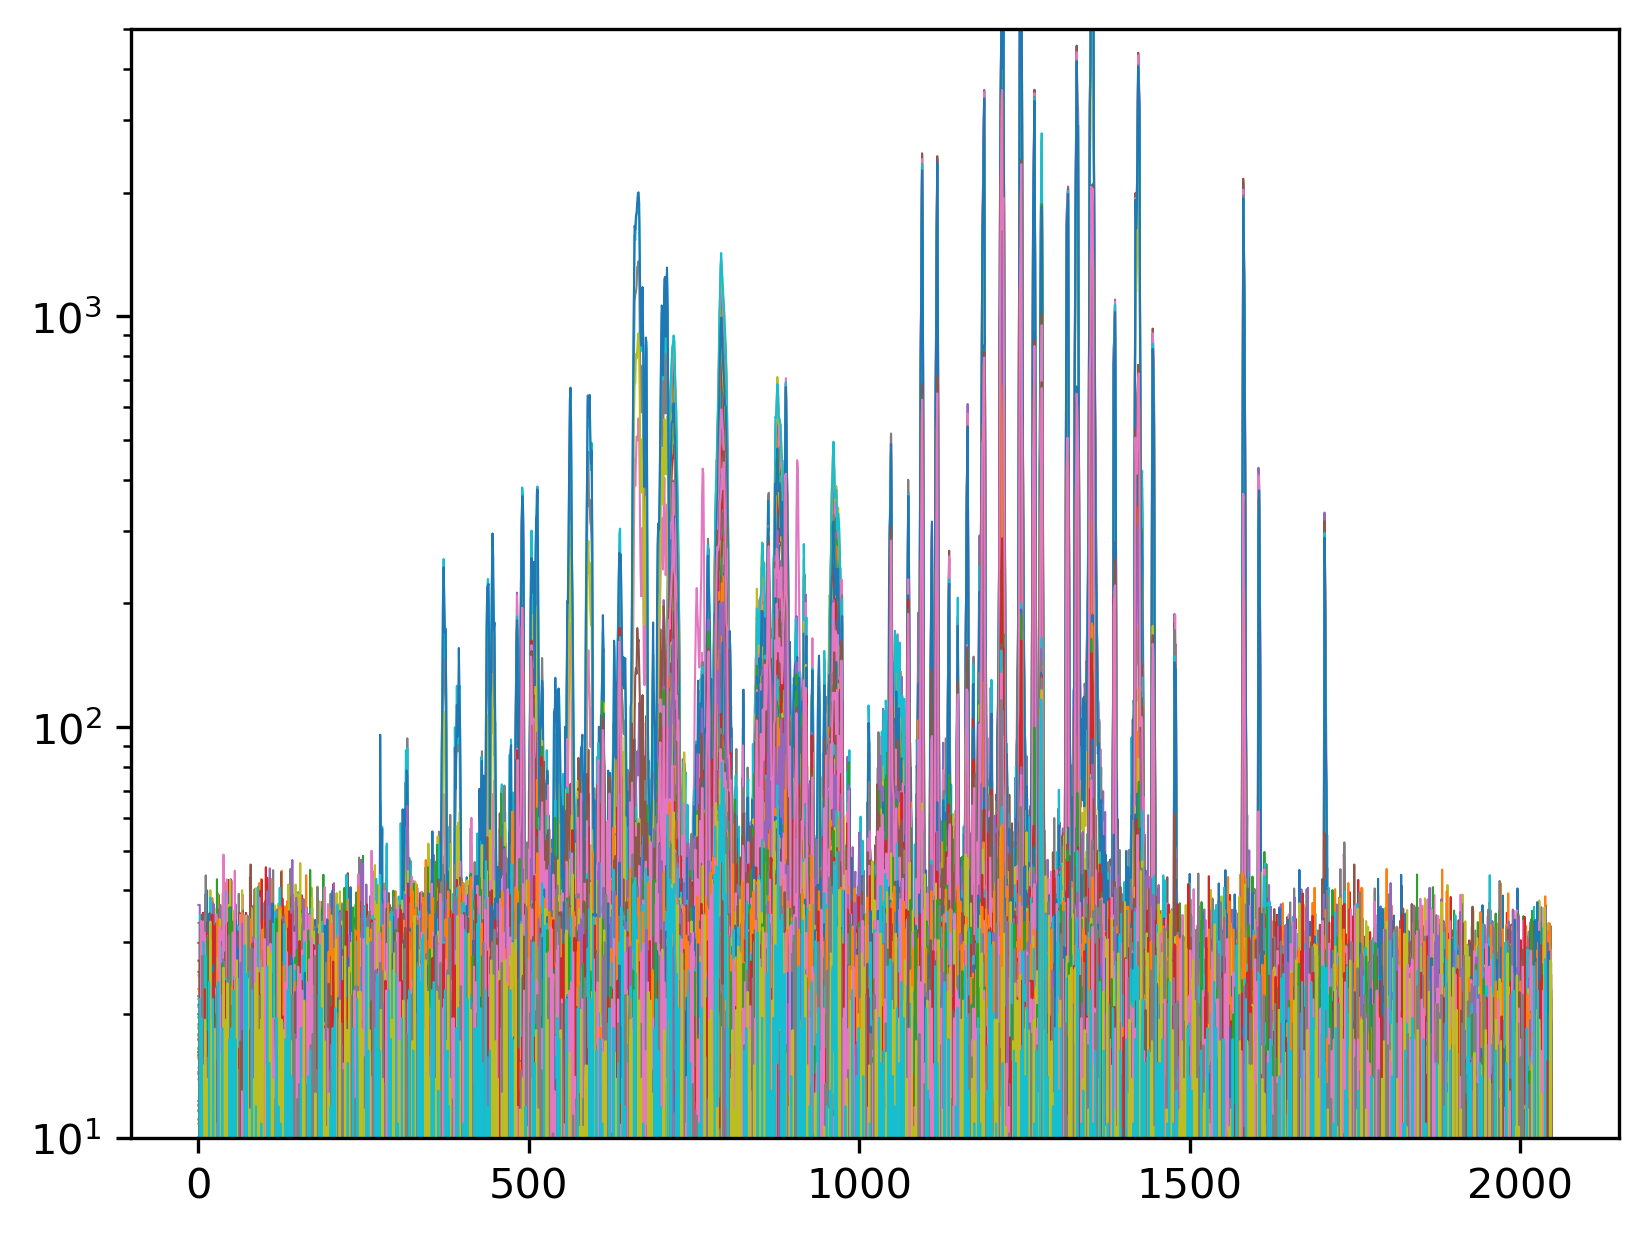

In [71]:
plt.figure(dpi=300)
for i in range(0,20000,100):
    plt.semilogy(specs_df['spec'][i], lw=0.5)
plt.ylim(10,5e3)